# 🔍 Exploration du Dataset — Classification de Tweets Haineux

Ce notebook couvre :
1. Chargement & aperçu général
2. Distribution des classes
3. Analyse de la longueur des tweets
4. Qualité des données (nulls, doublons)
5. Analyse lexicale (mots fréquents, nuages de mots)
6. Analyse des caractères spéciaux (emojis, URLs, mentions)
7. Conclusions & recommandations preprocessing

## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from collections import Counter
from wordcloud import WordCloud

# NLTK pour stopwords français
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords


sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('✅ Imports OK')

✅ Imports OK


## 1. Chargement des données



In [3]:
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/TER/Data/corpus_haineux.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# ─────────────────────────────────────────────
#  CONFIGURATION — à modifier selon ton CSV
# ─────────────────────────────────────────────
CSV_PATH  = '/content/drive/MyDrive/TER/Data/corpus_haineux.csv'  # chemin vers ton fichier
TEXT_COL  = 'tweet'            # nom de la colonne texte
LABEL_COL = 'label'           # nom de la colonne label (0/1 ou haineux/non-haineux)
SEP       = ';'               # séparateur CSV
ENCODING  = 'utf-8'           # encodage (essaie 'latin-1' si erreur)
# ─────────────────────────────────────────────

df = pd.read_csv(CSV_PATH, sep=SEP, encoding=ENCODING)

print(f'📦 Shape : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'\n📋 Colonnes : {list(df.columns)}')
df.head()

📦 Shape : 600 lignes × 2 colonnes

📋 Colonnes : ['tweet', 'label']


,tweet,label
0,Tous ces migrants qui envahissent nos hôpitaux...,1
1,Les #migrants #maghrebins qui envahissent la🇫🇷...,1
2,#Immigration #islamistes #racailles \n,1
3,@philippe_dormoy @F_Desouche Retour à la cas...,1
4,"oui, mais y'a soros (ami de macron, soit dit e...",1


## 2. Aperçu général

In [8]:
print('='*55)
print('INFOS GÉNÉRALES')
print('='*55)
df.info()
print()
print('─'*55)
print('TYPES DES COLONNES')
print(df.dtypes)
print()
print('─'*55)
print('STATISTIQUES DESCRIPTIVES (colonnes numériques)')
df.describe()

INFOS GÉNÉRALES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   tweet   600 non-null    object
 1   label   600 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 9.5+ KB

───────────────────────────────────────────────────────
TYPES DES COLONNES
tweet    object
label     int64
dtype: object

───────────────────────────────────────────────────────
STATISTIQUES DESCRIPTIVES (colonnes numériques)


,label
count,600.000000
mean,0.500000
std,0.500417
min,0.000000
25%,0.000000
50%,0.500000
75%,1.000000
max,1.000000


## 3. Qualité des données

In [9]:
print('='*55)
print('VALEURS MANQUANTES')
print('='*55)
nulls = df.isnull().sum()
pct   = (nulls / len(df) * 100).round(2)
null_df = pd.DataFrame({'count': nulls, 'pct (%)': pct})
print(null_df[null_df['count'] > 0] if null_df['count'].sum() > 0 else '✅ Aucune valeur manquante')

print()
print('='*55)
print('DOUBLONS')
print('='*55)
n_dup_full  = df.duplicated().sum()
n_dup_text  = df[TEXT_COL].duplicated().sum()
print(f'Lignes entièrement dupliquées : {n_dup_full:,} ({n_dup_full/len(df)*100:.1f}%)')
print(f'Tweets dupliqués (texte seul) : {n_dup_text:,} ({n_dup_text/len(df)*100:.1f}%)')

# Exemples de doublons si présents
if n_dup_text > 0:
    print('\nExemples de tweets dupliqués :')
    dup_examples = df[df[TEXT_COL].duplicated(keep=False)].sort_values(TEXT_COL).head(6)
    display(dup_examples[[TEXT_COL, LABEL_COL]])

VALEURS MANQUANTES
✅ Aucune valeur manquante

DOUBLONS
Lignes entièrement dupliquées : 22 (3.7%)
Tweets dupliqués (texte seul) : 22 (3.7%)

Exemples de tweets dupliqués :


,tweet,label
73,@AldoSterone111 De plus en plus je les déteste...,1
162,@AldoSterone111 De plus en plus je les déteste...,1
164,@AmbassadeChine Putain de communistes bridés! ...,1
217,@AmbassadeChine Putain de communistes bridés! ...,1
126,@gwennavec2n JSUIS ABATTU SA MÈRE LA@PUTE DES ...,1
151,@gwennavec2n JSUIS ABATTU SA MÈRE LA@PUTE DES ...,1


In [10]:
print('='*55)
print('LABELS — valeurs uniques')
print('='*55)
print(df[LABEL_COL].value_counts())
print(f'\nType du label : {df[LABEL_COL].dtype}')

LABELS — valeurs uniques
label
1    300
0    300
Name: count, dtype: int64

Type du label : int64


## 4. Distribution des classes

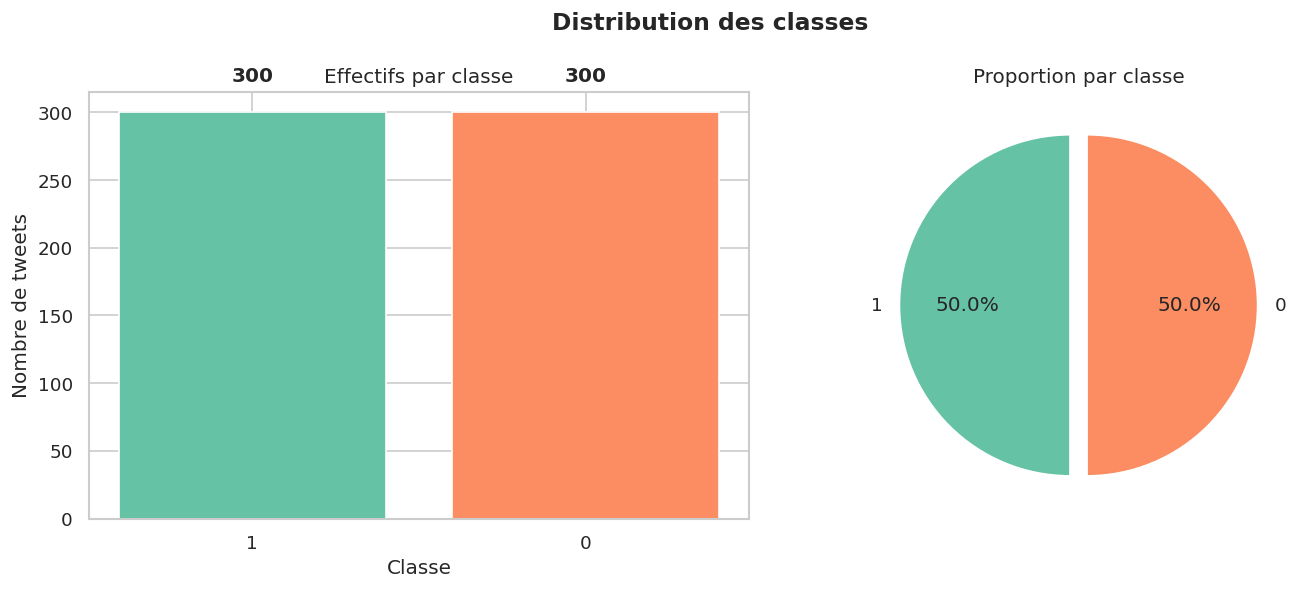


📊 Résumé des classes :
       Effectif  Proportion (%)
label                          
1           300            50.0
0           300            50.0

✅ Classes relativement équilibrées (ratio = 1.0x)


In [11]:
counts = df[LABEL_COL].value_counts()
pcts   = df[LABEL_COL].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribution des classes', fontsize=14, fontweight='bold')

# Barplot
bars = axes[0].bar(counts.index.astype(str), counts.values,
                   color=sns.color_palette('Set2', len(counts)))
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Nombre de tweets')
axes[0].set_title('Effectifs par classe')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index.astype(str),
            autopct='%1.1f%%', colors=sns.color_palette('Set2', len(counts)),
            startangle=90, explode=[0.05]*len(counts))
axes[1].set_title('Proportion par classe')

plt.tight_layout()
plt.show()

# Tableau récapitulatif
print('\n📊 Résumé des classes :')
summary = pd.DataFrame({'Effectif': counts, 'Proportion (%)': pcts.round(1)})
print(summary)

# Alerte déséquilibre
ratio = counts.max() / counts.min()
if ratio > 3:
    print(f'\n⚠️  Déséquilibre important ! Ratio max/min = {ratio:.1f}x')
    print('   → Penser à class_weight="balanced" dans les modèles')
    print('   → Utiliser F1-score et non accuracy comme métrique principale')
else:
    print(f'\n✅ Classes relativement équilibrées (ratio = {ratio:.1f}x)')

## 5. Analyse de la longueur des tweets

In [12]:
df['nb_chars']  = df[TEXT_COL].str.len()
df['nb_words']  = df[TEXT_COL].str.split().str.len()
df['nb_tokens'] = df[TEXT_COL].str.split().str.len()  # même chose ici, à affiner avec tokenizer

print('='*55)
print('LONGUEUR DES TWEETS')
print('='*55)
for col, label in [('nb_chars', 'Caractères'), ('nb_words', 'Mots')]:
    print(f'\n{label} :')
    print(df[col].describe().round(1).to_string())

LONGUEUR DES TWEETS

Caractères :
count    600.0
mean     159.4
std       78.2
min       16.0
25%       95.8
50%      143.5
75%      217.0
max      374.0

Mots :
count    600.0
mean      25.7
std       12.9
min        3.0
25%       15.0
50%       23.0
75%       36.0
max       69.0


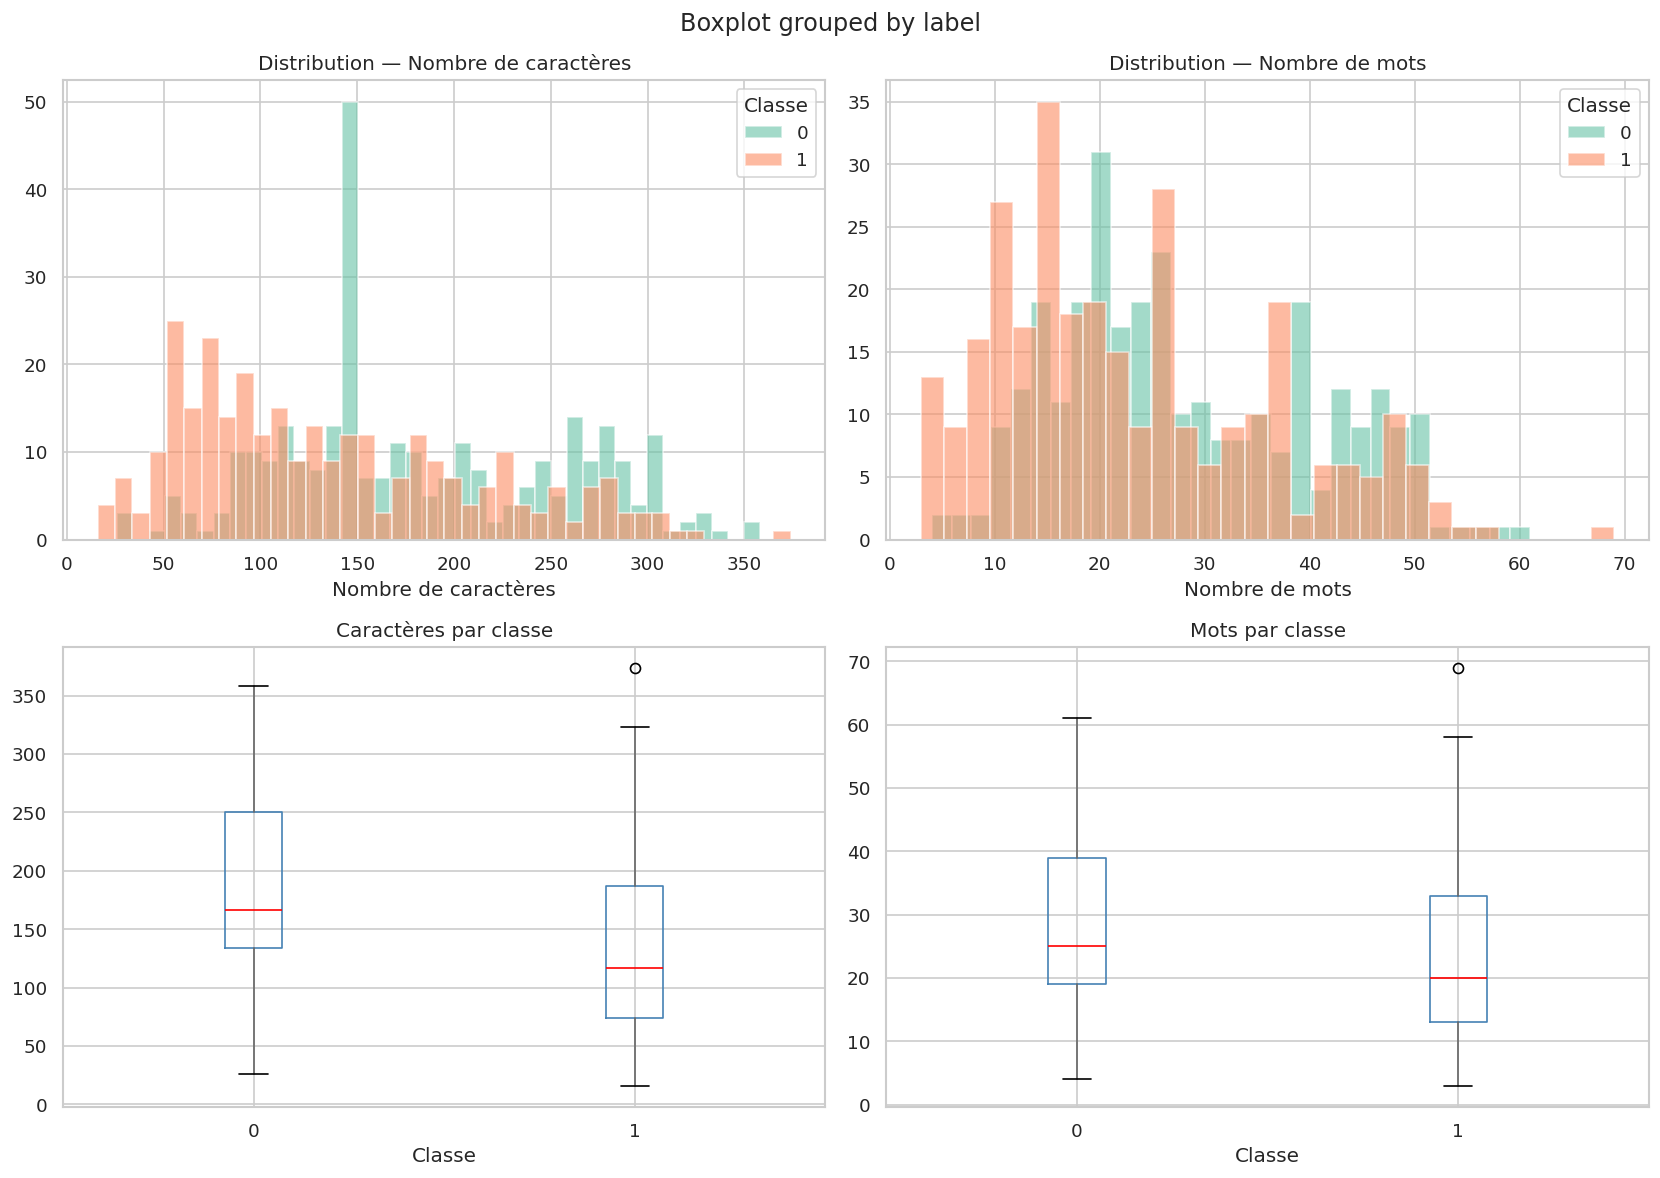

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analyse de la longueur des tweets', fontsize=14, fontweight='bold')

palette = sns.color_palette('Set2', df[LABEL_COL].nunique())

# Distribution nb caractères
for i, (label, grp) in enumerate(df.groupby(LABEL_COL)):
    axes[0,0].hist(grp['nb_chars'], bins=40, alpha=0.6, label=str(label), color=palette[i])
axes[0,0].set_title('Distribution — Nombre de caractères')
axes[0,0].set_xlabel('Nombre de caractères')
axes[0,0].legend(title='Classe')

# Distribution nb mots
for i, (label, grp) in enumerate(df.groupby(LABEL_COL)):
    axes[0,1].hist(grp['nb_words'], bins=30, alpha=0.6, label=str(label), color=palette[i])
axes[0,1].set_title('Distribution — Nombre de mots')
axes[0,1].set_xlabel('Nombre de mots')
axes[0,1].legend(title='Classe')

# Boxplot nb caractères par classe
df.boxplot(column='nb_chars', by=LABEL_COL, ax=axes[1,0],
           boxprops=dict(color='steelblue'), medianprops=dict(color='red'))
axes[1,0].set_title('Caractères par classe')
axes[1,0].set_xlabel('Classe')
plt.sca(axes[1,0])
plt.title('Caractères par classe')

# Boxplot nb mots par classe
df.boxplot(column='nb_words', by=LABEL_COL, ax=axes[1,1],
           boxprops=dict(color='steelblue'), medianprops=dict(color='red'))
axes[1,1].set_xlabel('Classe')
plt.sca(axes[1,1])
plt.title('Mots par classe')

plt.tight_layout()
plt.show()

In [14]:
print('📊 Longueur moyenne par classe :')
print(df.groupby(LABEL_COL)[['nb_chars','nb_words']].mean().round(1))

📊 Longueur moyenne par classe :
       nb_chars  nb_words
label                    
0         183.1      28.2
1         135.7      23.1


## 6. Analyse des éléments spéciaux (URLs, mentions, emojis)

In [15]:
df['nb_urls']      = df[TEXT_COL].str.count(r'http\S+|www\.\S+')
df['nb_mentions']  = df[TEXT_COL].str.count(r'@\w+')
df['nb_hashtags']  = df[TEXT_COL].str.count(r'#\w+')
df['nb_emojis']    = df[TEXT_COL].str.count(
    r'[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF'
    r'\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF'
    r'\U00002700-\U000027BF\U0001F900-\U0001F9FF]'
)
df['nb_exclamations'] = df[TEXT_COL].str.count(r'!')
df['pct_majuscules']  = df[TEXT_COL].apply(
    lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1) * 100
)

special_cols = ['nb_urls','nb_mentions','nb_hashtags','nb_emojis','nb_exclamations','pct_majuscules']

print('📊 Moyennes des éléments spéciaux par classe :')
print(df.groupby(LABEL_COL)[special_cols].mean().round(2))

📊 Moyennes des éléments spéciaux par classe :
       nb_urls  nb_mentions  nb_hashtags  nb_emojis  nb_exclamations  \
label                                                                  
0         0.48         1.06         0.34       0.28             0.17   
1         0.17         0.78         0.21       0.18             0.24   

       pct_majuscules  
label                  
0                5.36  
1                5.92  


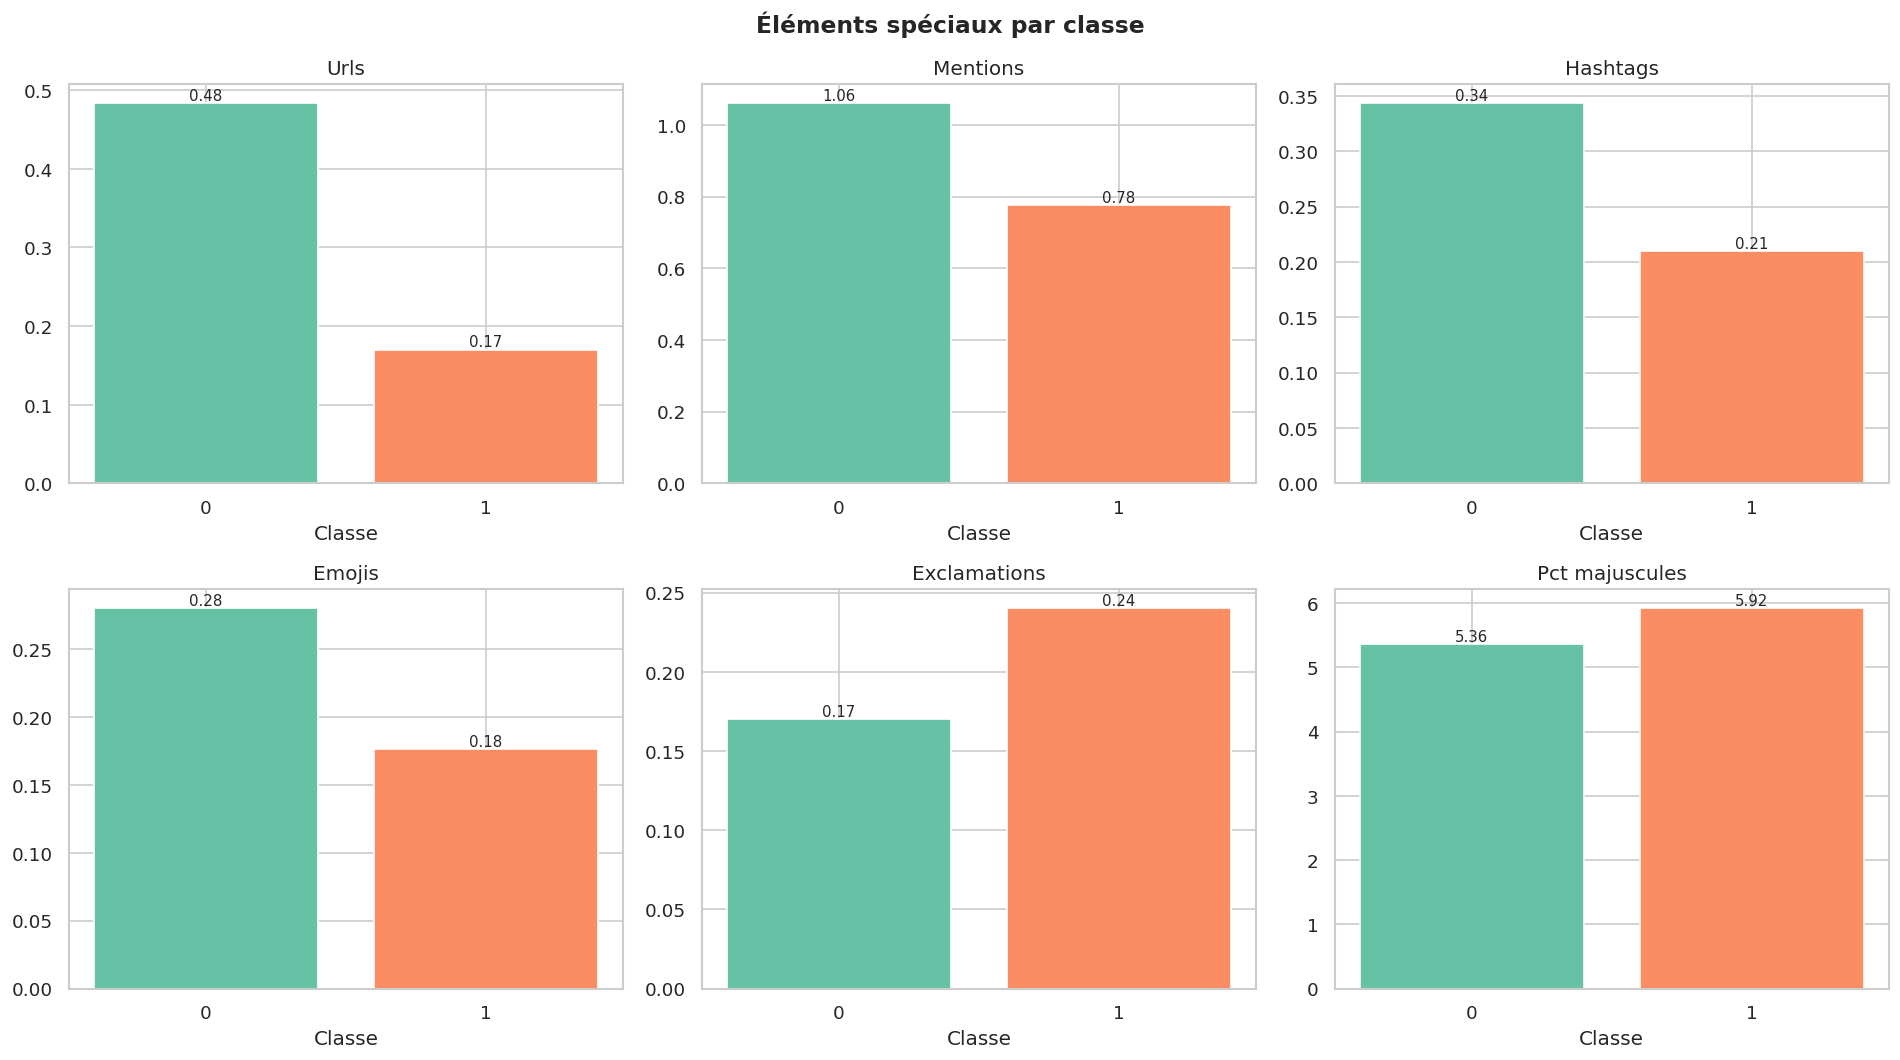

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Éléments spéciaux par classe', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flat, special_cols):
    means = df.groupby(LABEL_COL)[col].mean()
    bars  = ax.bar(means.index.astype(str), means.values,
                   color=sns.color_palette('Set2', len(means)))
    ax.set_title(col.replace('nb_', '').replace('_', ' ').capitalize())
    ax.set_xlabel('Classe')
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Analyse lexicale — mots les plus fréquents

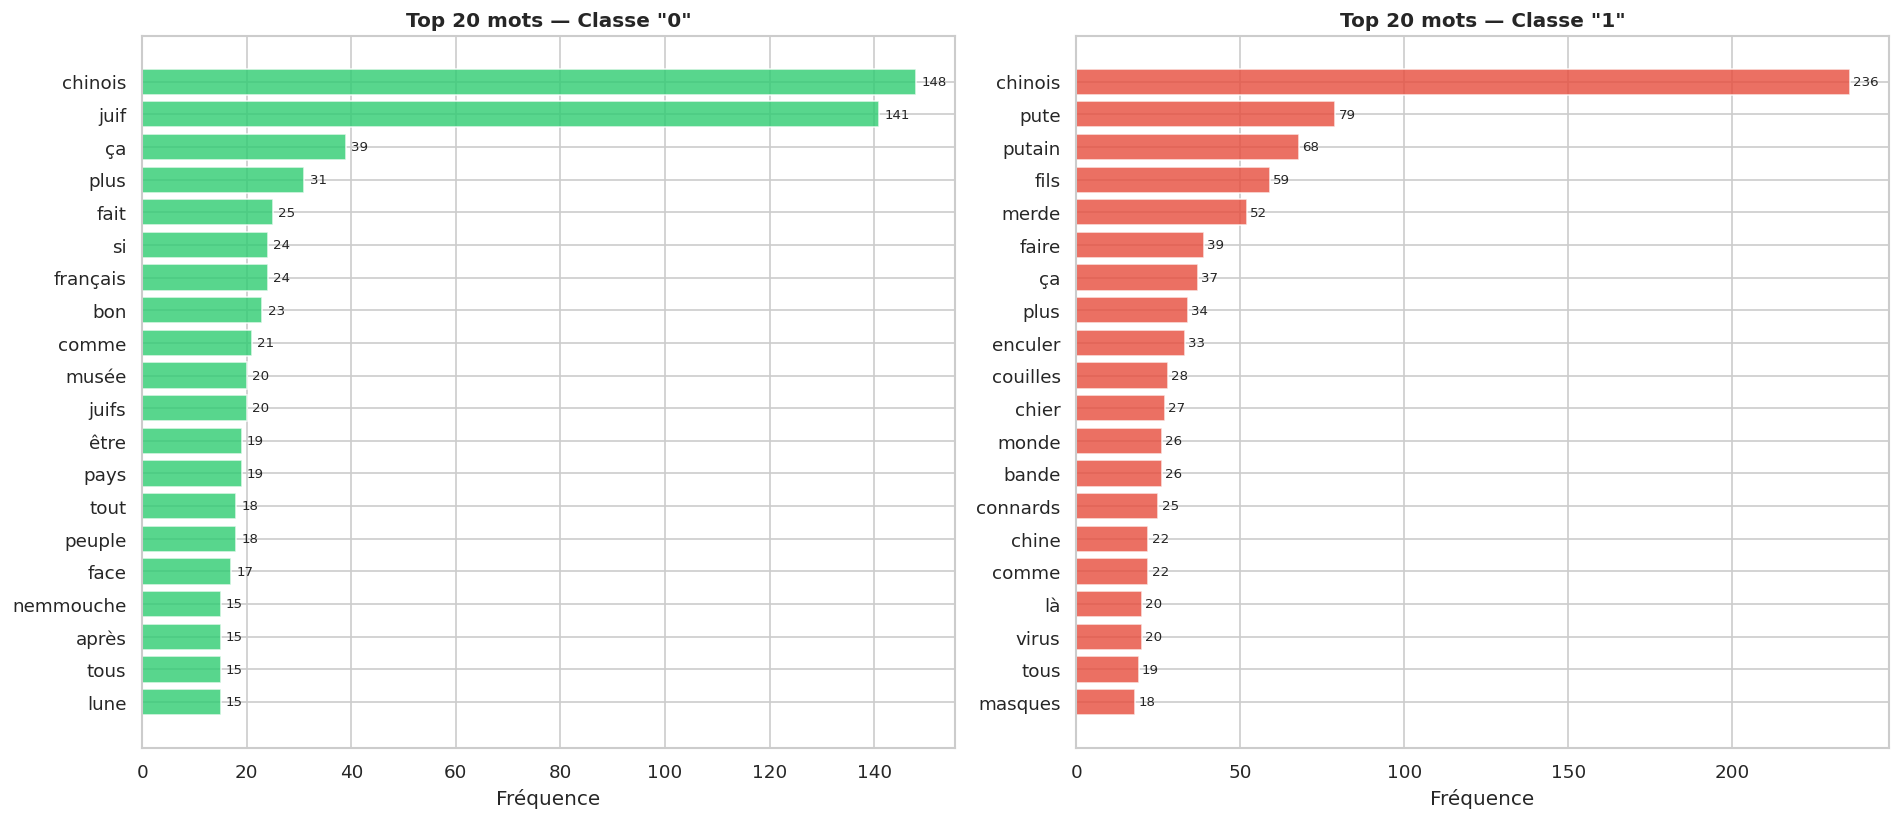

In [17]:
STOP_FR = set(stopwords.words('french'))
# Stopwords supplémentaires spécifiques aux tweets
STOP_FR.update(['rt', 'via', 'cc', 'http', 'https', 'co', 'amp', 'tweet'])

def get_top_words(texts, n=30, stop=STOP_FR):
    """Retourne les n mots les plus fréquents (hors stopwords)."""
    all_words = []
    for text in texts:
        text = re.sub(r'http\S+|@\w+|#', '', str(text).lower())
        words = re.findall(r'\b[a-záàâäéèêëîïôöùûüç]{2,}\b', text)
        all_words.extend([w for w in words if w not in stop])
    return Counter(all_words).most_common(n)

labels_unique = sorted(df[LABEL_COL].unique())

fig, axes = plt.subplots(1, len(labels_unique), figsize=(8*len(labels_unique), 7))
if len(labels_unique) == 2:
    axes = [axes] if len(labels_unique) == 1 else axes

for ax, label in zip(axes, labels_unique):
    subset = df[df[LABEL_COL] == label][TEXT_COL]
    top    = get_top_words(subset, n=20)
    words, freqs = zip(*top)
    
    color = '#E74C3C' if str(label) in ['1','haineux','hate'] else '#2ECC71'
    bars = ax.barh(list(reversed(words)), list(reversed(freqs)), color=color, alpha=0.8)
    ax.set_title(f'Top 20 mots — Classe "{label}"', fontweight='bold')
    ax.set_xlabel('Fréquence')
    for bar, val in zip(bars, list(reversed(freqs))):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 8. Nuages de mots

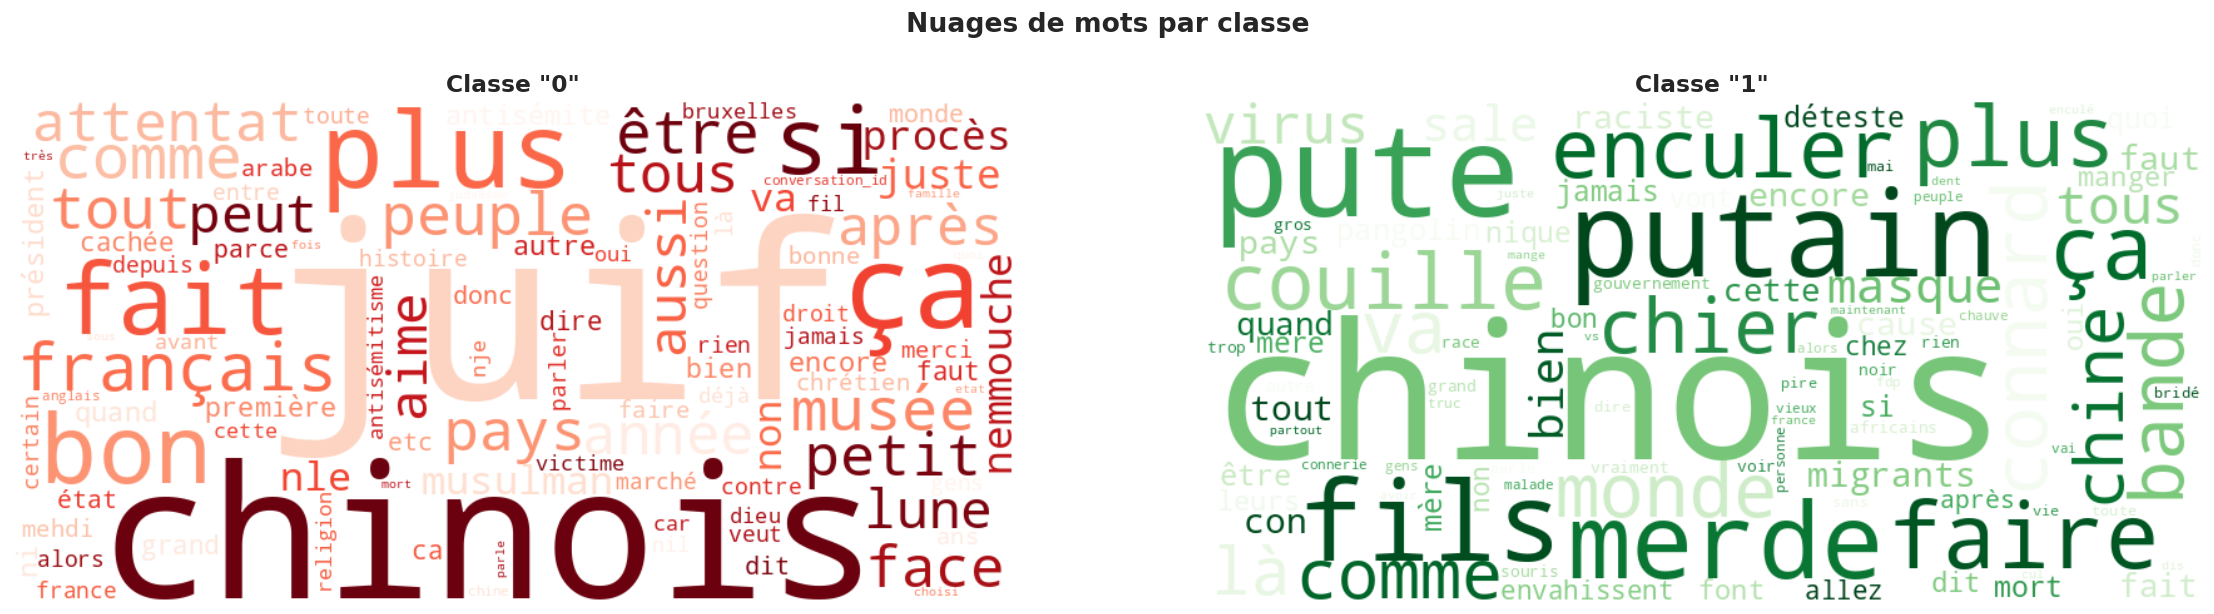

In [18]:
def make_wordcloud(texts, title, colormap='Reds'):
    combined = ' '.join(texts)
    combined = re.sub(r'http\S+|@\w+|#\w+', '', combined.lower())
    combined = re.sub(r'\b(' + '|'.join(STOP_FR) + r')\b', '', combined)
    
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=colormap,
        max_words=100,
        collocations=False
    ).generate(combined)
    return wc

fig, axes = plt.subplots(1, len(labels_unique), figsize=(10*len(labels_unique), 5))
if len(labels_unique) == 1:
    axes = [axes]

cmaps = ['Reds', 'Greens', 'Blues', 'Purples']
for ax, label, cmap in zip(axes, labels_unique, cmaps):
    subset = df[df[LABEL_COL] == label][TEXT_COL].astype(str)
    wc     = make_wordcloud(subset, str(label), colormap=cmap)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Classe "{label}"', fontsize=14, fontweight='bold')

plt.suptitle('Nuages de mots par classe', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Analyse des hashtags et mentions fréquents

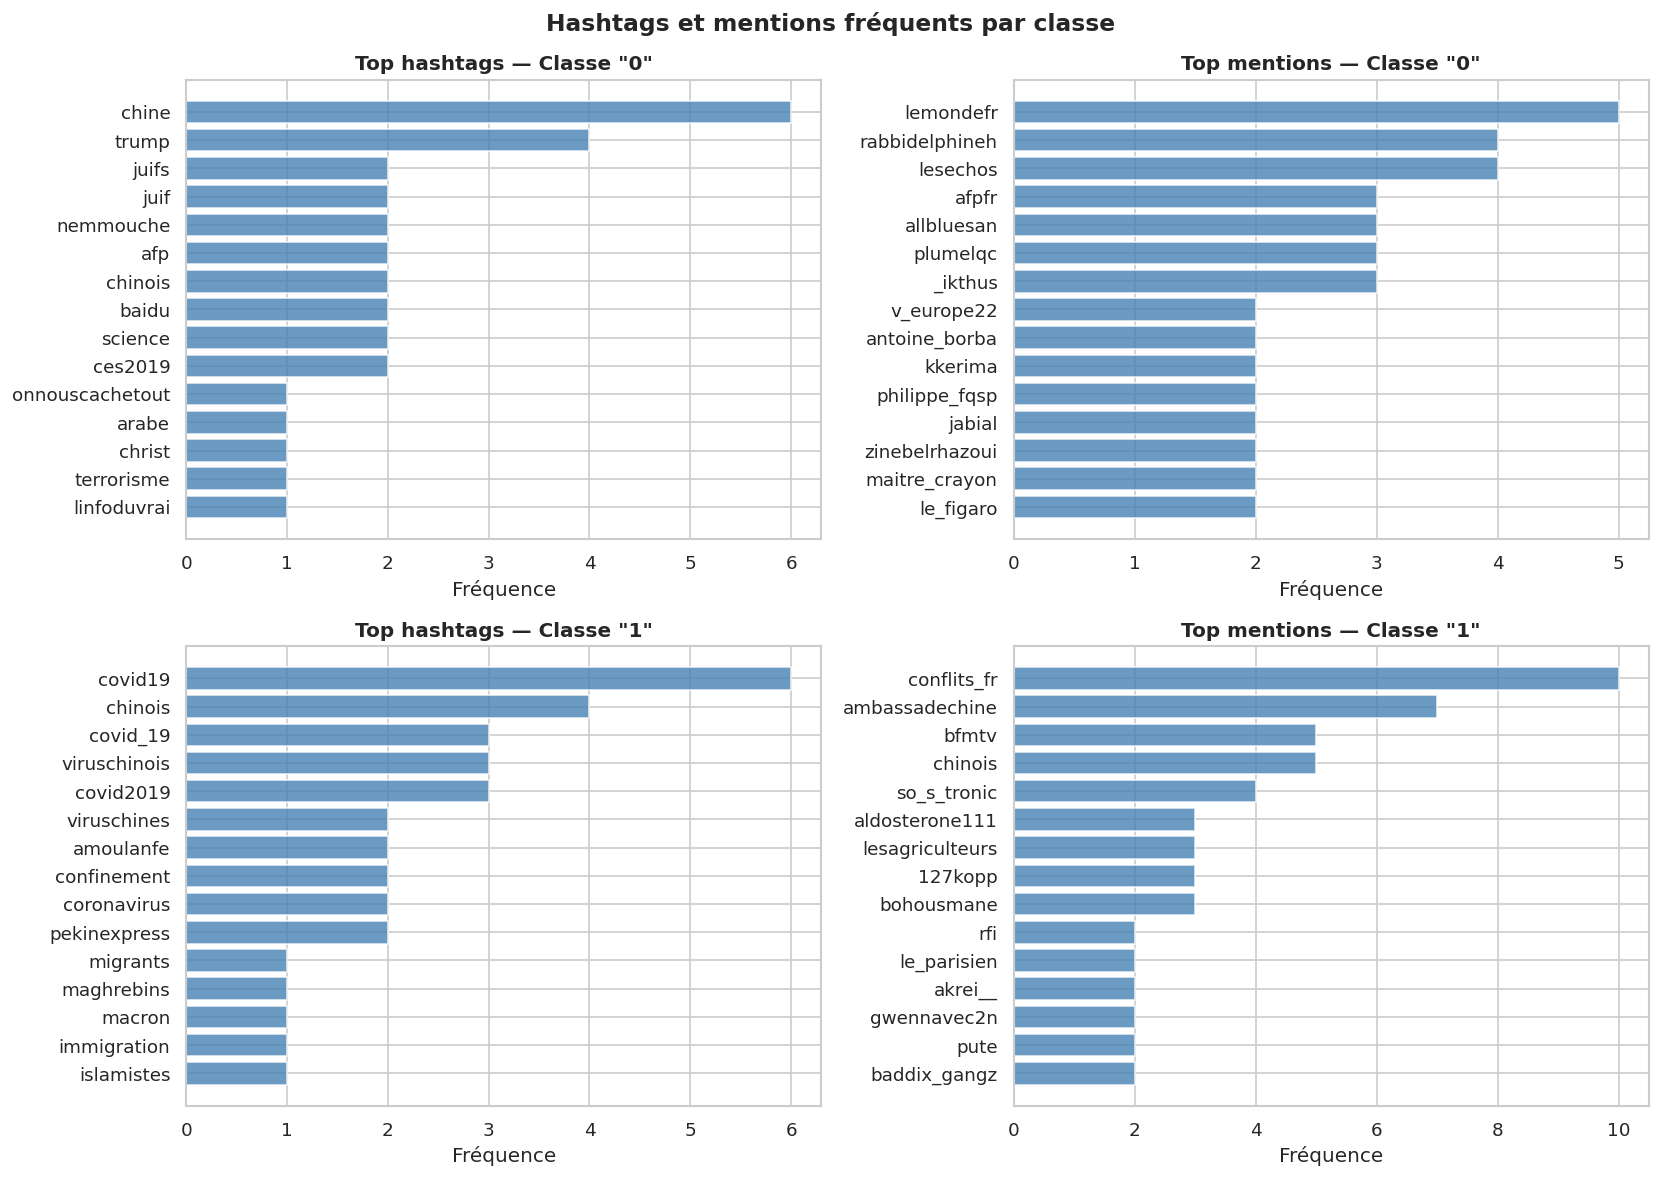

In [19]:
def extract_elements(texts, pattern):
    elements = []
    for text in texts:
        elements.extend(re.findall(pattern, str(text).lower()))
    return Counter(elements).most_common(15)

fig, axes = plt.subplots(len(labels_unique), 2, figsize=(14, 5*len(labels_unique)))
fig.suptitle('Hashtags et mentions fréquents par classe', fontsize=14, fontweight='bold')

if len(labels_unique) == 1:
    axes = [axes]

for row_axes, label in zip(axes, labels_unique):
    subset = df[df[LABEL_COL] == label][TEXT_COL]
    
    for ax, (pattern, title) in zip(row_axes, [
        (r'#(\w+)', f'Top hashtags — Classe "{label}"'),
        (r'@(\w+)', f'Top mentions — Classe "{label}"'),
    ]):
        top = extract_elements(subset, pattern)
        if top:
            words, freqs = zip(*top)
            ax.barh(list(reversed(words)), list(reversed(freqs)),
                    color='steelblue', alpha=0.8)
            ax.set_title(title, fontweight='bold')
            ax.set_xlabel('Fréquence')
        else:
            ax.text(0.5, 0.5, 'Aucun élément trouvé',
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(title)

plt.tight_layout()
plt.show()

## 10. Exemples de tweets par classe

In [20]:
N_EXEMPLES = 5

for label in labels_unique:
    print(f'\n{'='*60}')
    print(f'  CLASSE "{label}" — {N_EXEMPLES} exemples aléatoires')
    print(f'{'='*60}')
    samples = df[df[LABEL_COL] == label][TEXT_COL].sample(
        min(N_EXEMPLES, len(df[df[LABEL_COL] == label])), random_state=42
    )
    for i, tweet in enumerate(samples, 1):
        print(f'{i}. {tweet[:200]}')


  CLASSE "0" — 5 exemples aléatoires
1. La conquête du marché chinois est décidément l'un des axes stratégiques pour vous distancier de vos concurrents, grâce à la taille et aux besoins encore émergeants de produits/services de qualité de c
2. Corée du Nord. En visite à Pékin, Kim Jong-un cherche l'appui de son grand voisin chinois  https://t.co/XLpeSGPqNt

3. Mon thé de tous les jours, c'est le thé noir (les Chinois disent rouge) fumé, le Lapsong Souchong. On en trouve de moins en moins, parce qu'il devenu moins rentable que d'autres pour les Chinois. Chez
4. @maelmonnier @Antoine_Borba @FRANCENOUVELLE5 +précismnt les juifs ne sont qu'1 interface entre Dieu et l'humanité afin que l'humanité reconnaisse Sa gloire et le monothéisme rejettnt l'idolâtrie C'est
5. Souvenirs de la magnifique expo #ZaoWouKi, présentée en 2018 au @MAM.\nUne réunion des peintures et des encres de grand format de l'artiste chinois, produites entre les années 1950 et le début du XXIe

  CLASSE "1" — 5 exemples 

## 11. Récapitulatif & Recommandations

In [21]:
print('='*60)
print('  RÉCAPITULATIF DE L\'EXPLORATION')
print('='*60)

n_total  = len(df)
n_null   = df[TEXT_COL].isnull().sum()
n_dup    = df[TEXT_COL].duplicated().sum()
ratio    = df[LABEL_COL].value_counts().max() / df[LABEL_COL].value_counts().min()
avg_len  = df['nb_words'].mean()

print(f'\n📦 Dataset : {n_total:,} tweets')
print(f'   • Valeurs manquantes  : {n_null}')
print(f'   • Doublons (texte)    : {n_dup}')
print(f'   • Ratio déséquilibre  : {ratio:.1f}x')
print(f'   • Longueur moy.       : {avg_len:.1f} mots/tweet')

print(f'\n🛠️  RECOMMANDATIONS PREPROCESSING')
print('-'*50)

if n_dup > 0:
    print(f'⚠️  Supprimer les {n_dup} doublons avant de splitter train/test')
if n_null > 0:
    print(f'⚠️  Gérer les {n_null} valeurs manquantes (suppression conseillée)')
if ratio > 3:
    print(f'⚠️  Déséquilibre {ratio:.1f}x → utiliser class_weight="balanced"')
    print('   → Métriques : F1-macro, AUC-ROC plutôt qu\'accuracy')

url_pct  = (df['nb_urls'] > 0).mean() * 100
emoji_pct = (df['nb_emojis'] > 0).mean() * 100
maj_mean  = df['pct_majuscules'].mean()

print(f'\n📝 Étapes de nettoyage recommandées :')
print(f'   ✓ Supprimer les URLs         ({url_pct:.0f}% des tweets en contiennent)')
print(f'   ✓ Traiter les emojis         ({emoji_pct:.0f}% des tweets en contiennent)')
print(f'   ✓ Normaliser les répétitions (hoooon → hon)')
print(f'   ✓ Lowercase')
if maj_mean > 5:
    print(f'   ✓ Conserver le ratio majuscules comme feature ({maj_mean:.1f}% moyen)')
print(f'   ✓ Stemming Snowball (FR) — robuste au bruit des tweets')
print(f'\n🔢 Représentation recommandée :')
print(f'   TF-IDF avec ngram_range=(1,2), sublinear_tf=True, max_features=50000')

  RÉCAPITULATIF DE L'EXPLORATION

📦 Dataset : 600 tweets
   • Valeurs manquantes  : 0
   • Doublons (texte)    : 22
   • Ratio déséquilibre  : 1.0x
   • Longueur moy.       : 25.7 mots/tweet

🛠️  RECOMMANDATIONS PREPROCESSING
--------------------------------------------------
⚠️  Supprimer les 22 doublons avant de splitter train/test

📝 Étapes de nettoyage recommandées :
   ✓ Supprimer les URLs         (28% des tweets en contiennent)
   ✓ Traiter les emojis         (9% des tweets en contiennent)
   ✓ Normaliser les répétitions (hoooon → hon)
   ✓ Lowercase
   ✓ Conserver le ratio majuscules comme feature (5.6% moyen)
   ✓ Stemming Snowball (FR) — robuste au bruit des tweets

🔢 Représentation recommandée :
   TF-IDF avec ngram_range=(1,2), sublinear_tf=True, max_features=50000


In [27]:
# ─────────────────────────────────────────────────────────────
# Détection des mots étirés : puuuuutain, noooon, trrrop...
# ─────────────────────────────────────────────────────────────

SEUIL_REPEAT = 3  # nb min de répétitions consécutives pour être détecté



pattern_repeat = re.compile(r'([a-zA-ZÀ-ÿ!?.,;:\-])\1{' + str(SEUIL_REPEAT - 1) + r',}', re.IGNORECASE)

def extraire_mots_etires(text):
    """Retourne les mots contenant des répétitions de caractères."""
    mots = re.findall(r'\b\w+\b', str(text).lower())
    return [m for m in mots if pattern_repeat.search(m)]

def normaliser_mot(mot):
    """puuuuutain → putain : réduit toute série de caractères identiques à 1."""
    return re.sub(r'(.)\1{2,}', r'\1', mot)

df['mots_etires']    = df[TEXT_COL].apply(extraire_mots_etires)
df['nb_mots_etires'] = df['mots_etires'].apply(len)
df['a_mot_etire']    = df['nb_mots_etires'] > 0

n_tweets_etires = df['a_mot_etire'].sum()
print(f'Tweets avec au moins un mot étiré : {n_tweets_etires:,} ({n_tweets_etires/len(df)*100:.1f}%)')
print(f'Seuil : {SEUIL_REPEAT} caractères consécutifs identiques\n')

# Top 30 mots étirés
all_etires = [mot for liste in df['mots_etires'] for mot in liste]
top_etires = Counter(all_etires).most_common(30)

print('=' * 55)
print('TOP 30 MOTS ÉTIRÉS (toutes classes)')
print('=' * 55)
print(f'{"Mot étiré":<25} {"Normalisé":<20} {"Occurrences"}')
print('-' * 55)
for mot, cnt in top_etires:
    print(f'{mot:<25} {normaliser_mot(mot):<20} {cnt}')

Tweets avec au moins un mot étiré : 19 (3.2%)
Seuil : 3 caractères consécutifs identiques

TOP 30 MOTS ÉTIRÉS (toutes classes)
Mot étiré                 Normalisé            Occurrences
-------------------------------------------------------
w4tlkkkdel                w4tlkdel             2
mdrrr                     mdr                  2
noooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooon non                  1
xptdrrrrr                 xptdr                1
mdrrrrrr                  mdr                  1
une_princessss            une_princes          1
ptdrrr                    ptdr                 1
turk1shhh                 turk1sh              1
luv4jooon                 luv4jon              1
blackkkberry94            blackberry94         1
maximeeegrt               maximegrt            1
shellyazzz                shellyaz             1
265aaa6kio                265a6kio             1
miammm                    miam                 1
wouaaaa                   woua 

In [25]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 8.4 MB/s eta 0:00:00:00:010:01


In [26]:
# Afficher tous les tweets contenant au moins un emoji
import emoji

mask_emoji = df[TEXT_COL].apply(lambda x: any(c in emoji.EMOJI_DATA for c in str(x)))
df_emojis  = df[mask_emoji].copy()

print(f'Tweets avec au moins un emoji : {len(df_emojis):,} ({len(df_emojis)/len(df)*100:.1f}%)\n')

for _, row in df_emojis.iterrows():
    emojis_trouves = [c for c in str(row[TEXT_COL]) if c in emoji.EMOJI_DATA]
    print(f'[Classe {row[LABEL_COL]}] {str(row[TEXT_COL])[:150]}')
    print(f'  -> emojis : {" ".join(emojis_trouves)}')
    print()

Tweets avec au moins un emoji : 50 (8.3%)

[Classe 1] @Dimitri_R C est super joli !!! 😍 😍 😍 Putain y aura toujours des connards pour critiquer, si elle sait faire de jolies robes réfléchissez, elle a auss
  -> emojis : 😍 😍 😍

[Classe 1] @Conflits_FR @EU_Commission Un tout grand Merci à vous Taïwan👏🏽👏🏽vous au moins vous offrez c pas comme la Chine eux qui on"créé"ce cauchemar ils profi
  -> emojis : 👏 🏽 👏 🏽 🤬

[Classe 1] @MartinFabienne8 Oui j'ai vue où il en mettent 😡😡😡 Les SDF français peuvent crever et nous aussi avec ce gvt 😡😡😡 Et les migrants qui ont pris la tange
  -> emojis : 😡 😡 😡 😡 😡 😡

[Classe 1] @manuila1 @AndropovIouri @MathildePanot @FranceInsoumise En dissimulant le nbre de chinois✝️depuis novembre 2019 le #PCommuniste Chinois a encore trom
  -> emojis : ✝

[Classe 1] Aux 100millions✝️du communisme il faudra ajouter les✝️ du #viruschinois #COVID19 

  -> emojis : ✝ ✝

[Classe 1] @lesagriculteurs @fresstoofresh C’est vraiment des fdp les #chinois il ont contaminé tout la te